In [1]:
import fetch
data = fetch.sjc_threemonths()
data.index.name = "date"
data = data.reset_index().drop_duplicates("date", keep="last")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib
from pathlib import Path
from scipy.interpolate import make_interp_spline, BSpline
import numpy as np
import pandas_ta as ta
import mplfinance as mpf

In [7]:
df = pd.DataFrame()
df["Open"] = data["buy"]
df["Close"] = data["sell"]
df["High"] = data["buy"].shift(1)
df["Low"] = data["sell"].shift(1)
# data["deltaBuy"] = (data["buy"] - data.shift(1)["buy"]).clip(0).shift(-1)
# data["deltaSell"] = (data["sell"] - data.shift(1)["sell"]).clip(0).shift(-1)
# up = data[data["buy"] >= data.shift(1)["buy"]]
# down = data[data["buy"] < data.shift(1)["buy"]]
# data

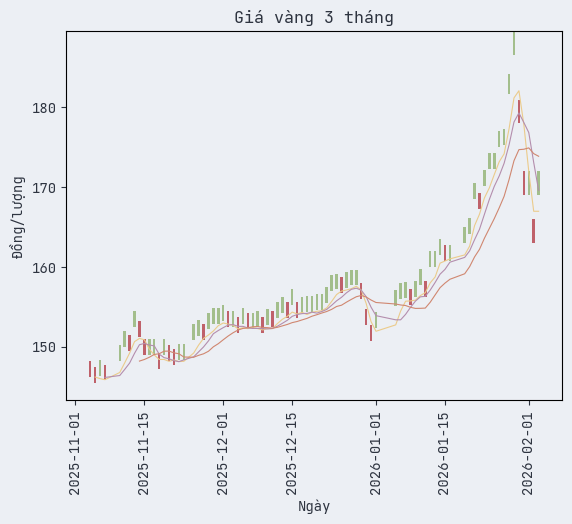

In [6]:

color_up = "#a3be8c"
color_down = "#bf616a"
width_candle = 0.5
width_wick = 0.2
font_path = "./assets/JetBrainsMono-Regular.ttf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.figure(facecolor="#eceff4")
plt.rcParams["text.color"] = "#2e3440"
plt.rcParams["axes.labelcolor"] = "#2e3440"
plt.rcParams["xtick.color"] = "#2e3440"
plt.rcParams["ytick.color"] = "#2e3440"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = prop.get_name()
plt.rcParams["figure.dpi"] = 300
plt.gca().set_facecolor("#eceff4")
plt.title("Giá vàng 3 tháng")

# Set axis label colors
plt.xlabel("Ngày")
plt.tick_params(axis="x", rotation=90)
plt.ylabel("Đồng/lượng")

plt.bar(up["date"], up["buy"] - up["sell"], width_candle, bottom=up.sell, color=color_up)
# plt.bar(up["date"], up.deltaBuy, width_wick, bottom=up.buy, color=color_up)

# Plotting down prices of the stock
plt.bar(down["date"], down["buy"] - down["sell"], width_candle, bottom=down.sell, color=color_down)
# plt.bar(down["date"], down.deltaSell, width_wick, bottom=down.sell - down.deltaSell, color=color_down)

# plt.bar(down["date"], down.low - down.close, width_wick, bottom=down.close, color=color_down)

plt.plot(data["date"], data["buy"].rolling(window=3).mean(), lw=0.8, color="#ebcb8b")
plt.plot(data["date"], data["buy"].rolling(window=5).mean(), lw=0.8, color="#b48ead")
plt.plot(data["date"], data["buy"].rolling(window=10).mean(), lw=0.8, color="#d08770")

plt.show()

In [24]:
df = pd.read_csv("datasets/snapshotdb.csv")

In [26]:
df["vendor"]

0     SJC
1    DOJI
2     PNJ
3    BTMC
4    BTMH
Name: vendor, dtype: str